## Imports & Libraries

In [1]:
# !pip install cugraph-cu12==25.2.0 -q

In [2]:
# import cudf
# import cugraph
# import cupy as cp

In [3]:
import pandas as pd
import numpy as np
import requests
import io

import networkx as nx

## Read File

In [5]:
def read_gdf_from_github(url):
    response = requests.get(url)
    lines = response.text.splitlines()

    node_section = False
    edge_section = False
    nodes = []
    edges = []

    for L in lines:
        L = L.strip()
        if L.lower().startswith('nodedef>'):
            node_section = True
            edge_section = False
            cols = L.split('>')[1].split(',')
            continue
        if L.lower().startswith('edgedef>'):
            edge_section = True
            node_section = False
            cols_e = L.split('>')[1].split(',')
            continue
        if node_section and L:
            parts = L.split(',')
            nodes.append(parts[0])
        if edge_section and L:
            parts = L.split(',')
            src = parts[0]
            dst = parts[1]
            if 'weight' in [c.lower() for c in cols_e]:
                w_idx = [c.lower() for c in cols_e].index('weight')
                w = float(parts[w_idx])
            else:
                w = 1.0
            edges.append((src, dst, w))

    return nodes, edges


gdf_url = 'https://raw.githubusercontent.com/amirkasaei/Social-and-Economic-Networks/refs/heads/main/HW/HW2/hamian-israeil.gdf'


nodes, edges = read_gdf_from_github(gdf_url)

In [6]:
def create_graph_from_data(nodes, edges):
    """
    Builds and returns a directed graph from node IDs and edge list.
    """
    G = nx.DiGraph()
    for n in nodes:
        G.add_node(n)
    for u, v, w in edges:
        G.add_edge(u, v, weight=w)
    return G

## New Metric (Viral Centrality)

In [11]:
# Create a directed, weighted graph
G = create_graph_from_data(nodes, edges)

# Compute Viral Centrality for each node
vc_scores = {}
for node in G.nodes():
    score = 0
    for neighbor in G.successors(node):
        weight = G[node][neighbor].get('weight', 1)
        out_deg = G.out_degree(neighbor)
        score += weight * np.log1p(out_deg)  # log(1 + OutDegree)
    vc_scores[node] = score

# Convert to DataFrame for analysis
vc_df = pd.DataFrame(vc_scores.items(), columns=['Id', 'ViralCentrality'])
vc_df_sorted = vc_df.sort_values(by='ViralCentrality', ascending=False)

# Display or save top nodes
print(vc_df_sorted.head(50))  # Top 10 nodes by Viral Centrality


                       Id  ViralCentrality
381             518692321        33.438408
2410  1589767478347026433        30.787455
429             719596352        28.659458
169              50599149        26.305866
2151  1568303753115144194        25.120091
1514  1271892865082368004        24.003047
2798  1676213344062021632        21.094739
3048  1771277006438612993        17.523191
74               23231946        17.276204
1012   908580919132459008        13.581381
996    893757772025798656        12.661083
1878  1465843476780695561        12.368464
2543  1618897435199213568        12.054947
963    874330245037527040         9.383537
2942  1712243355201978368         6.552508
1894  1473294329804324870         4.465908
1302  1112025263850901506         1.945910
1349  1163760331002392577         1.945910
2054  1530479308157984768         0.000000
2055  1530705108593520640         0.000000
2053  1530246921171873792         0.000000
2056  1531010899372384258         0.000000
2057  15310

In [10]:
vc_df_sorted.to_csv('ViralCentrality.csv', index=False)

## K Estimation

In [ ]:
G = create_graph_from_data(nodes, edges)

In [ ]:
len(edges)

4743

### Random Walk

In [ ]:
# Compute the random-walk Laplacian matrix
L_rw = nx.linalg.directed_laplacian_matrix(G, weight='weight', walk_type='random', alpha=0.9)

/usr/local/lib/python3.11/dist-packages/networkx/linalg/laplacianmatrix.py:596: RuntimeWarning: divide by zero encountered in divide
  DI = sp.sparse.csr_array(sp.sparse.spdiags(1.0 / A.sum(axis=1), 0, n, n))
/usr/local/lib/python3.11/dist-packages/networkx/linalg/laplacianmatrix.py:442: RuntimeWarning: divide by zero encountered in divide
  @ sp.sparse.csr_array(sp.sparse.spdiags(1.0 / sqrtp, 0, n, n))


In [ ]:
# After building L, clean infs and NaNs
L = np.nan_to_num(L_rw, nan=0.0, posinf=0.0, neginf=0.0)

from scipy.linalg import eigh

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigh(L)

# Display first few eigenvalues
print("First 10 eigenvalues:", eigenvalues[:10])

First 10 eigenvalues: [0.44444444 0.48840314 0.57075092 0.65593914 0.72797948 0.7899911
 0.81052309 0.86160783 0.88123504 0.91202998]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sort eigenvalues ascending
eigvals_sorted = np.sort(eigenvalues)

# Compute gaps between consecutive eigenvalues
gaps = np.diff(eigvals_sorted)

# Step 3: Find the largest gap (EigenGap)
max_gap_index = np.argmax(gaps)

# Estimated number of clusters = index of largest gap + 1
estimated_k = max_gap_index + 1


In [ ]:
print(f"✅ Largest gap is {gaps[max_gap_index]}.")
print(f"✅ Largest gap is at position {max_gap_index}.")
print(f"✅ Estimated number of clusters: {estimated_k} clusters.")

✅ Largest gap is 0.08518822264168313.
✅ Largest gap is at position 2.
✅ Estimated number of clusters: 3 clusters.


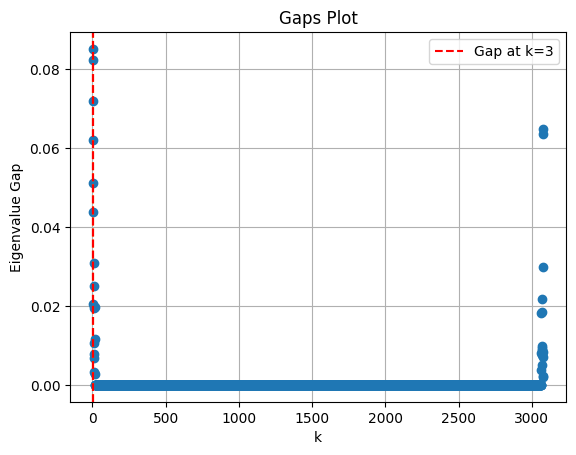

In [ ]:
# Plot for visualization
plt.plot(range(1, len(gaps)+1), gaps, 'o')
plt.xlabel('k')
plt.ylabel('Eigenvalue Gap')
plt.axvline(x=max_gap_index, color='r', linestyle='--')
plt.grid(True)
plt.axvline(x=estimated_k, color='orange', linestyle='--')
plt.axvline(x=estimated_k, color='r', linestyle='--', label=f'Gap at k={estimated_k}')
plt.title('Gaps Plot')
plt.legend()

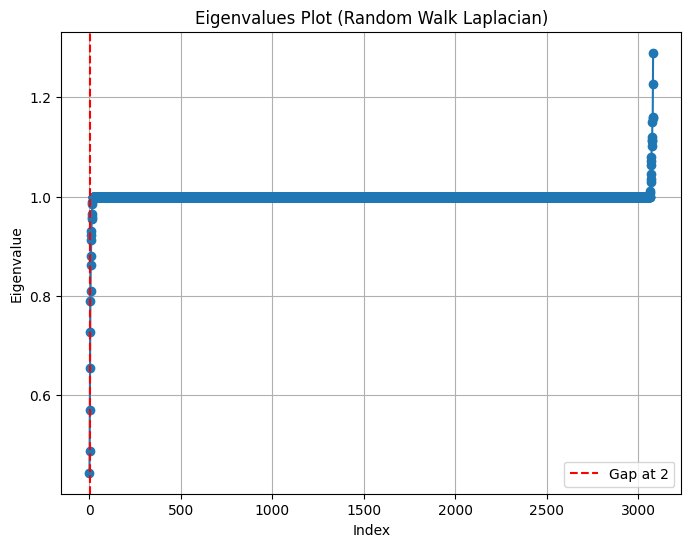

In [ ]:
# Plot eigenvalues
plt.figure(figsize=(8,6))
plt.plot(np.arange(1, len(eigvals_sorted)+1), eigvals_sorted, marker='o')
plt.axvline(x=estimated_k, color='r', linestyle='--', label=f'Gap at {max_gap_index}')
plt.title('Eigenvalues Plot (Random Walk Laplacian)')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.legend()
plt.show()

### Normalized

In [ ]:
# Compute the random-walk Laplacian matrix
L_n = nx.normalized_laplacian_matrix(G.to_undirected(), weight='weight')
L_n = L_n.todense()

In [ ]:
from scipy.linalg import eigh

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigh(L_n)

# Display first few eigenvalues
print("First 10 eigenvalues:", eigenvalues[:10])

First 10 eigenvalues: [2.22044605e-16 1.77635684e-15 4.25697573e-02 8.20051355e-02
 1.02139319e-01 1.42382463e-01 1.66666507e-01 2.06202604e-01
 2.14509441e-01 2.22870025e-01]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sort eigenvalues ascending
eigvals_sorted = np.sort(eigenvalues)

# Compute gaps between consecutive eigenvalues
gaps = np.diff(eigvals_sorted)

# Step 3: Find the largest gap (EigenGap)
max_gap_index = np.argmax(gaps)

# Estimated number of clusters = index of largest gap + 1
estimated_k = max_gap_index + 1


In [ ]:
print(f"✅ Largest gap is {gaps[max_gap_index]}.")
print(f"✅ Largest gap is at position {max_gap_index}.")
print(f"✅ Estimated number of clusters: {estimated_k} clusters.")

✅ Largest gap is 0.3041840791916911.
✅ Largest gap is at position 21.
✅ Estimated number of clusters: 22 clusters.


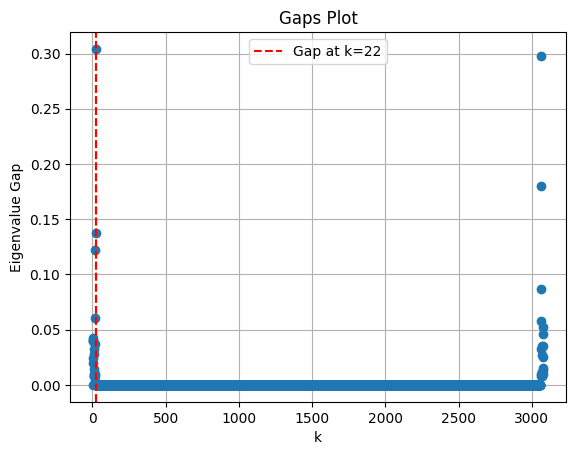

In [ ]:
# Plot for visualization
plt.plot(range(1, len(gaps)+1), gaps, 'o')
plt.xlabel('k')
plt.ylabel('Eigenvalue Gap')
plt.axvline(x=max_gap_index, color='r', linestyle='--')
plt.grid(True)
plt.axvline(x=estimated_k, color='orange', linestyle='--')
plt.axvline(x=estimated_k, color='r', linestyle='--', label=f'Gap at k={estimated_k}')
plt.title('Gaps Plot')
plt.legend()

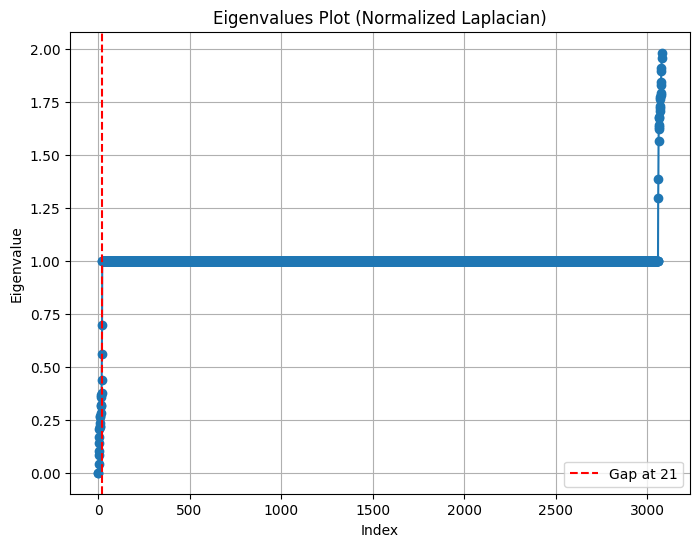

In [ ]:
# Plot eigenvalues
plt.figure(figsize=(8,6))
plt.plot(np.arange(1, len(eigvals_sorted)+1), eigvals_sorted, marker='o')
plt.axvline(x=estimated_k, color='r', linestyle='--', label=f'Gap at {max_gap_index}')
plt.title('Eigenvalues Plot (Normalized Laplacian)')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.legend()
plt.show()

## K Means

In [ ]:
from sklearn.cluster import KMeans

# Choose number of clusters k (based on previous estimation or manually set)
k = estimated_k

# Use the first k eigenvectors as spectral features
spectral_features = eigenvectors[:, :k]

# Run KMeans clustering
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(spectral_features)

# Create cluster DataFrame for node assignment
nodes_sorted = list(G.nodes())
cluster_df = pd.DataFrame({
    'Id': nodes_sorted,
    'Cluster': cluster_labels
})

In [ ]:
len(cluster_df)

3081

In [ ]:
cluster_df.to_csv('Cluster.csv', index=False)

In [ ]:
cluster_df.head()

,Id,Cluster
0,12,0
1,764537,0
2,788524,0
3,790728,13
4,1367531,9


In [ ]:
# Count frequency of each cluster
cluster_counts = cluster_df['Cluster'].value_counts().sort_index()
cluster_freq_df = pd.DataFrame({
    'Cluster': cluster_counts.index,
    'Frequency': cluster_counts.values
})

cluster_freq_df.sort_values(by='Frequency', ascending=False)

,Cluster,Frequency
11,11,874
0,0,628
1,1,544
12,12,217
4,4,180
18,18,162
6,6,136
17,17,79
14,14,75
8,8,74


### cugraph

In [ ]:
### MOVE DATA TO GPU (CUDF)

# Convert pandas DataFrame to cuDF DataFrame
edge_cudf = cudf.DataFrame.from_pandas(edge_df)
edge_cudf.head()

,Source,Target,Type,Id,Weight
0,1568303753115144194,1638320544788406273,Directed,0,247
1,1568303753115144194,1186590420626804737,Directed,1,75
2,1568303753115144194,1478147158859788290,Directed,2,180
3,1568303753115144194,1242287686095794176,Directed,3,22
4,1568303753115144194,1638372580464685056,Directed,4,230


In [ ]:
### BUILD GRAPH ON GPU

# Force node1 and node2 to int32
edge_cudf['Source'] = edge_cudf['Source'].astype('int32')
edge_cudf['Target'] = edge_cudf['Target'].astype('int32')

edge_cudf = edge_cudf.rename(columns={'Source': "src", 'Target': "dst", 'Weight': "weight"})


# Then build graph normally:
G = cugraph.Graph(directed=True)
G.from_cudf_edgelist(edge_cudf, source='src', destination='dst', edge_attr='weight')

print(f"\n✅ Graph has {G.number_of_vertices()} vertices and {G.number_of_edges()} edges.")


✅ Graph has 3055 vertices and 4743 edges.


In [ ]:
import cupy as cp

# Step 1: Prepare node mappings
nodes = G.nodes().to_pandas().sort_values().reset_index(drop=True)
node_to_idx = {node: idx for idx, node in enumerate(nodes)}
num_nodes = len(nodes)

# Step 2: Prepare edges with mapped indices
adj_coo = edge_cudf.copy()
adj_coo['src'] = adj_coo['src'].to_pandas().map(node_to_idx)
adj_coo['dst'] = adj_coo['dst'].to_pandas().map(node_to_idx)

# Step 3: Correct type casting for GPU
row = cp.array(adj_coo['src'].to_numpy(), dtype=cp.int32)
col = cp.array(adj_coo['dst'].to_numpy(), dtype=cp.int32)
data = cp.array(adj_coo['weight'].to_numpy(), dtype=cp.float32)

# Step 4: Build sparse adjacency matrix A
A = cp.sparse.coo_matrix((data, (row, col)), shape=(num_nodes, num_nodes)).tocsr()

print("✅ Built sparse adjacency matrix A.")

# Step 5: Compute out-degree matrix D_out
out_deg = cp.array(A.sum(axis=1)).flatten()
D = cp.diag(out_deg)

print("✅ Computed out-degree matrix D.")

# Step 6: Compute Laplacians

# 6.1 Unnormalized Laplacian: L = D - A
L = D - A
print("✅ Unnormalized Laplacian L computed.")

# 6.2 Random Walk Laplacian: L_rw = I - D^{-1} * A
out_deg_safe = cp.where(out_deg == 0, 1, out_deg)  # Avoid division by zero
D_inv = cp.diag(1.0 / out_deg_safe)

L_rw = cp.identity(num_nodes) - D_inv @ A
print("✅ Random Walk Laplacian L_rw computed.")

# Step 7: (Optional) Check shapes
print(f"L shape (unnormalized Laplacian): {L.shape}")
print(f"L_rw shape (Random Walk Laplacian): {L_rw.shape}")


✅ Built sparse adjacency matrix A.
✅ Computed out-degree matrix D.
✅ Unnormalized Laplacian L computed.
✅ Random Walk Laplacian L_rw computed.
L shape (unnormalized Laplacian): (3055, 3055)
L_rw shape (Random Walk Laplacian): (3055, 3055)


In [ ]:
# Step 1: Compute eigenvalues of Random Walk Laplacian
eigvals, eigvecs = cp.linalg.eigh(L_rw)

# Step 2: Move to CPU for easier plotting
# eigvals_cpu = cp.asnumpy(eigvals)  <-- This line is causing the error
eigvals_cpu = cp.asnumpy(eigvals)  # Get the first element (eigenvalues) from the tuple and convert it
eigvecs_cpu = cp.asnumpy(eigvecs)

print("✅ Eigenvalues computed.")
print(f"First few eigenvalues:\n{eigvals_cpu[:10]}")

✅ Eigenvalues computed.
First few eigenvalues:
[0.52669125 0.70371106 0.71698217 0.71720919 0.71924656 0.7204751
 0.80662879 0.81596903 0.83630211 0.83710709]
